In [9]:
import numpy as np
from risk_control_utils import (
    threshold_to_loss_vectorized_upper, threshold_to_loss_vectorized_lower, find_threshold, 
    sigmoid_func
)
from signal_util import load_log
import matplotlib.pyplot as plt

In [5]:
def lower_threshold_correctness_risk_v1(correctness, exit_points):
    """
    correctness: (T,) bool/int, per-step correctness, final correctness = correctness[-1]
    exit_points: (M,) int, exit time index in [0, T-1], or `no_exit` for no exit

    returns:
      risks_per_threshold: (M,) {0,1}
    """
    correctness = np.asarray(correctness).astype(bool)
    exit_points = np.asarray(exit_points)

    T = correctness.shape[0]
    final_correct = correctness[-1]

    # "no exit => no risk"
    did_exit = (exit_points != no_exit)

    # "exited early" (exiting at the final step is effectively not truncating)
    exited_early = did_exit & (exit_points < T - 1)

    return (final_correct & exited_early).astype(np.int32)


def lower_threshold_correctness_risk_v2(correctness, exit_points):
    exit_times = np.asarray(exit_points)
    correct_steps = np.asarray(correctness, dtype=bool)
    T = correct_steps.shape[0]
    suffix_sum = np.cumsum(correct_steps[::-1])[::-1].astype(np.float64)
    denom = np.arange(T, 0, -1, dtype=np.float64)  # T, T-1, ..., 1
    suffix_mean = suffix_sum / denom  # shape (T,)

    risks = np.zeros(exit_times.shape, dtype=np.float64)

    mask = (exit_times != no_exit_val)
    if np.any(mask):
        t = exit_times[mask].astype(int)
        if np.any(t < 0) or np.any(t >= T):
            bad = t[(t < 0) | (t >= T)]
            raise ValueError(f"Some exit_times out of range [0, {T-1}]: {bad[:10]}")
        risks[mask] = suffix_mean[t]

    return risks

In [6]:
def plot_binary_colored_line_loop(
    ax, x, y, b, color0="C0", color1="C3", **kwargs):
    x = np.asarray(x); y = np.asarray(y); b = np.asarray(b).astype(int)
    for i in range(len(x) - 1):
        ax.plot(x[i:i+2], y[i:i+2],
        color=(color1 if b[i] else color0),
        # label='correct' if b[i] else 'incorrect',
        **kwargs)

In [ ]:
dir = 'PATH TO LOG'  # --- IGNORE ---
all_log = load_log(dir)

In [38]:
all_log[0].keys()

dict_keys(['question', 'gold_answer', 'actual_final_answer', 'checkpoints', 'metadata', 'intermediate_checks', 'thinking_step', 'predicted_answer', 'confidence', 'intermediate_correct', 'tokens_used', 'entropy_uni', 'eat_uni', 'eat_uni_forced'])

In [11]:
def plf(tokens, shift=0, c=0.1):
    x = (tokens - shift) * c
    val = 1 / (1 + np.exp(-x))
    return val

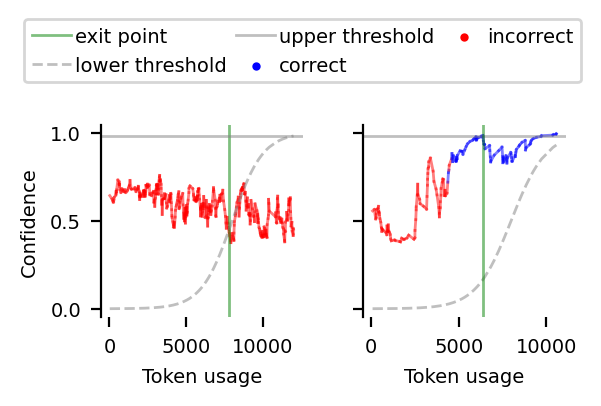

In [266]:
fig, ax = plt.subplots(1, 2, figsize=(3, 1.25), sharey=True)
fig.subplots_adjust(wspace=0.3)
line_config = {'linewidth': 1.0, 'alpha': 0.5}
FONTSIZE = 7
upper_threshold = 0.98
alpha = 0.2

id = 535
x = all_log[id]['tokens_used']

lower_threshold_value = plf(x, shift=8000, c=0.001)
confidence = ema_causal(all_log[id]['confidence'], alpha=alpha)
diff = confidence - lower_threshold_value
exit_idx = (diff <= 0).nonzero()[0][:1]

plot_binary_colored_line_loop(
    ax[0],
    x,
    ema_causal(all_log[id]['confidence'], alpha=alpha),
    all_log[id]['intermediate_correct'],
    color0='red', color1='blue',
    **line_config
)
ax[0].axvline(
    x[exit_idx],
    label='exit point',
    # linestyle=':', 
    c='green', **line_config)


ax[0].plot(
    x, plf(x, shift=8000, c=0.001),
    linestyle='--', label='lower threshold',
    c='gray',  **line_config)

ax[0].axhline(
    upper_threshold,
    linestyle='-', label='upper threshold',
    c='gray',  **line_config)

id = 816

x = all_log[id]['tokens_used']
confidence = ema_causal(all_log[id]['confidence'], alpha=alpha)
diff = upper_threshold - confidence
exit_idx = (diff <= 0).nonzero()[0][:1]

plot_binary_colored_line_loop(
    ax[1],
    x,
    ema_causal(all_log[id]['confidence'], alpha=alpha),
    all_log[id]['intermediate_correct'],
    color0='red', color1='blue',
    **line_config
)

ax[1].plot(
    x, plf(x, shift=8000, c=0.001),
    linestyle='--',
    c='gray',  **line_config)

ax[1].axhline(
    upper_threshold,
    linestyle='-',
    c='gray',  **line_config)

ax[1].axvline(
    x[exit_idx],
    label='exit point',
    # linestyle=':', 
    c='green', **line_config)

for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['bottom'].set_visible(False)
    # a.plot([0, 1], [0, 1], linestyle='--', color='gray', label='y=x')
    a.tick_params(axis='both', which='major', labelsize=FONTSIZE)
    a.set_xlabel('Token usage', fontsize=FONTSIZE)
ax[0].set_ylabel('Confidence', fontsize=FONTSIZE)
ax[0].scatter([], [], s=4, color='blue', label='correct')
ax[0].scatter([], [], s=4, color='red', label='incorrect')

ax[0].legend(
    fontsize=FONTSIZE,
    ncols=3,
    # bbox_to_anchor=(1.0, -0.4),
    bbox_to_anchor=(1.0, 1.6),
    loc='upper center',
    # REduce space between legend entries
    handletextpad=0.2,
    columnspacing=0.5,
)
plt.savefig('figures/threshold_viz.pdf', bbox_inches='tight')

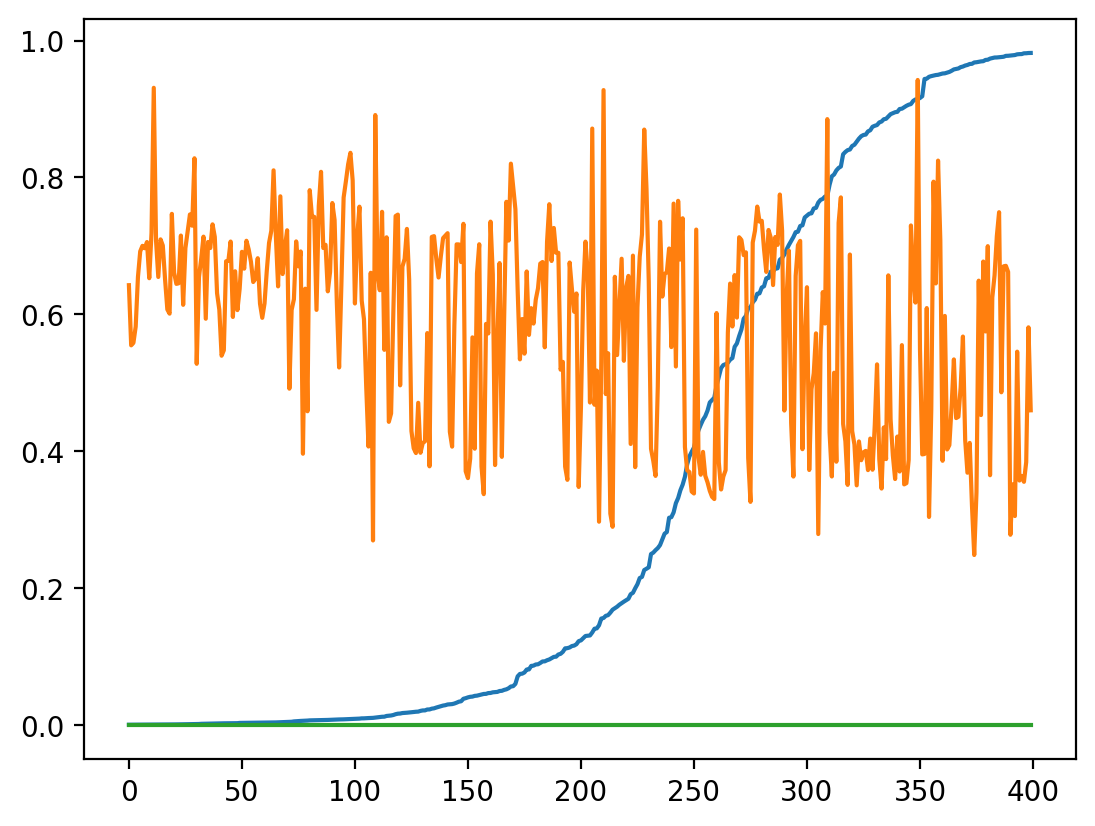

In [142]:
id = 535
x = all_log[id]['tokens_used']
plt.plot(plf(x, shift=8000, c=0.001))
plt.plot(ema_causal(all_log[id]['confidence'], alpha=0.9))
plt.plot(all_log[id]['intermediate_correct'])

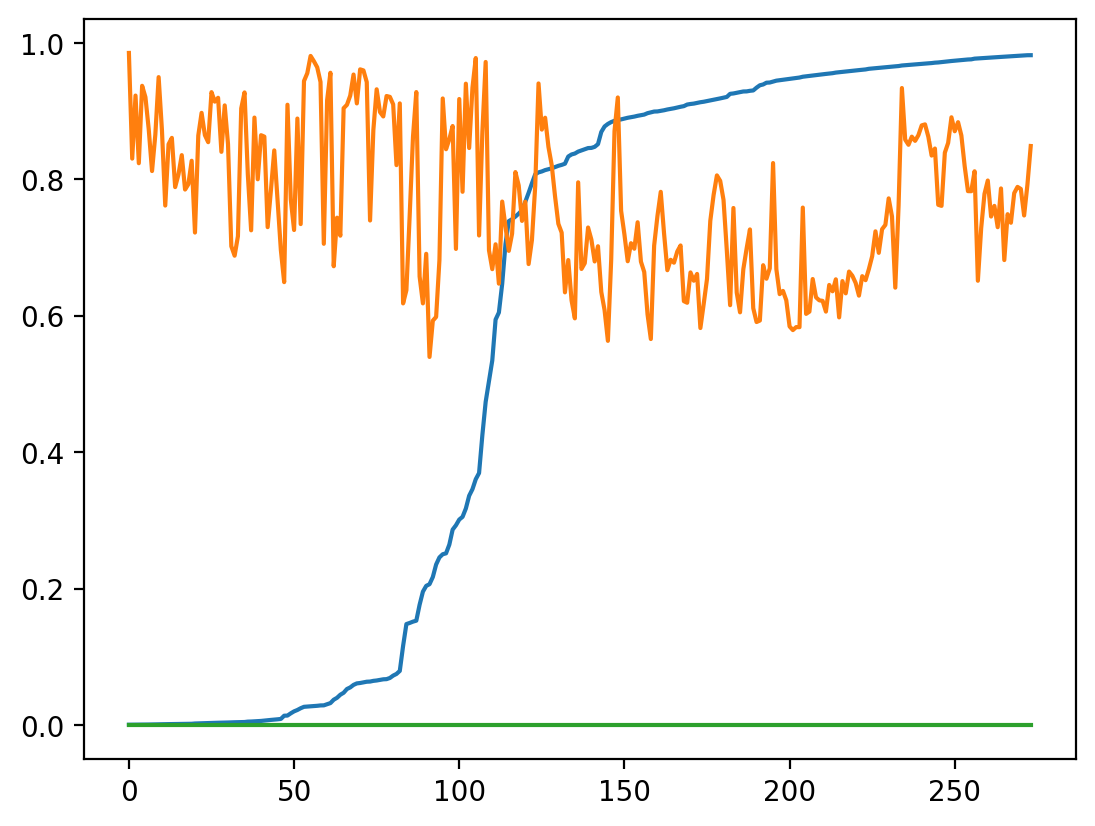

In [136]:
id = 521
x = all_log[id]['tokens_used']
plt.plot(plf(x, shift=8000, c=0.001))
plt.plot(ema_causal(all_log[id]['confidence'], alpha=0.9))
plt.plot(all_log[id]['intermediate_correct'])

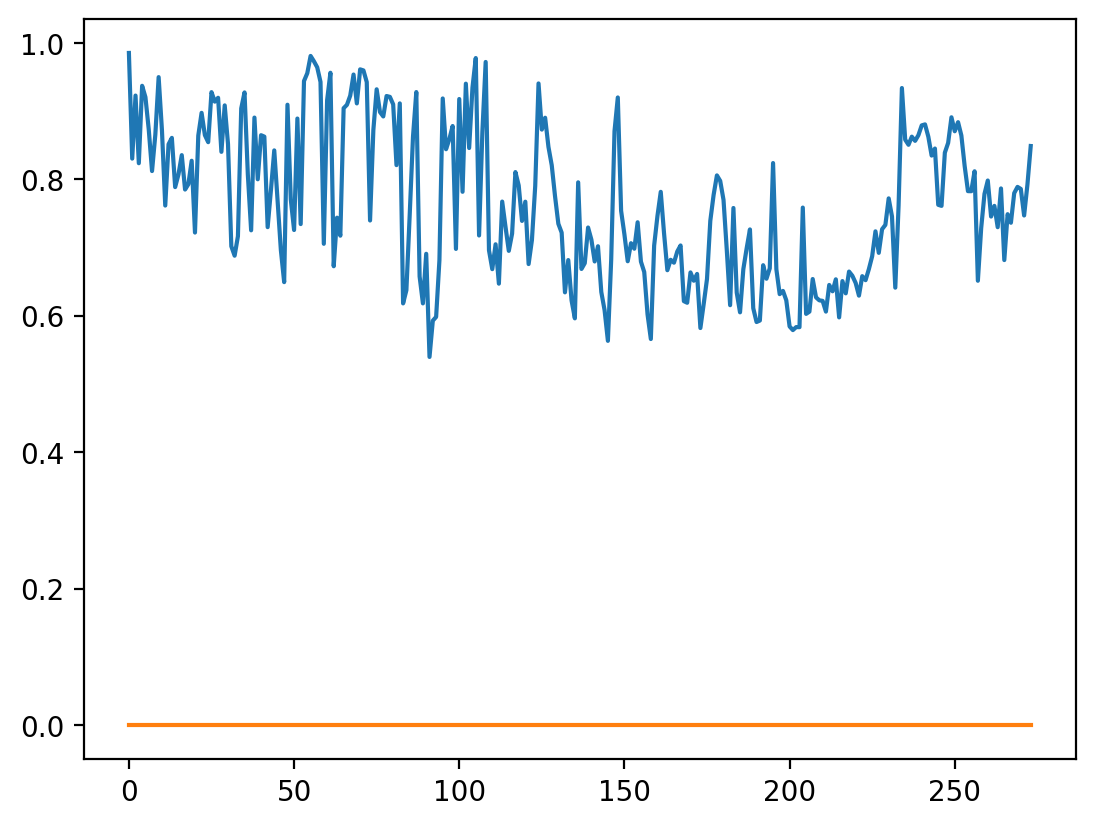

In [104]:
id = 521
plt.plot(ema_causal(all_log[id]['confidence'], alpha=0.9))
plt.plot(all_log[id]['intermediate_correct'])

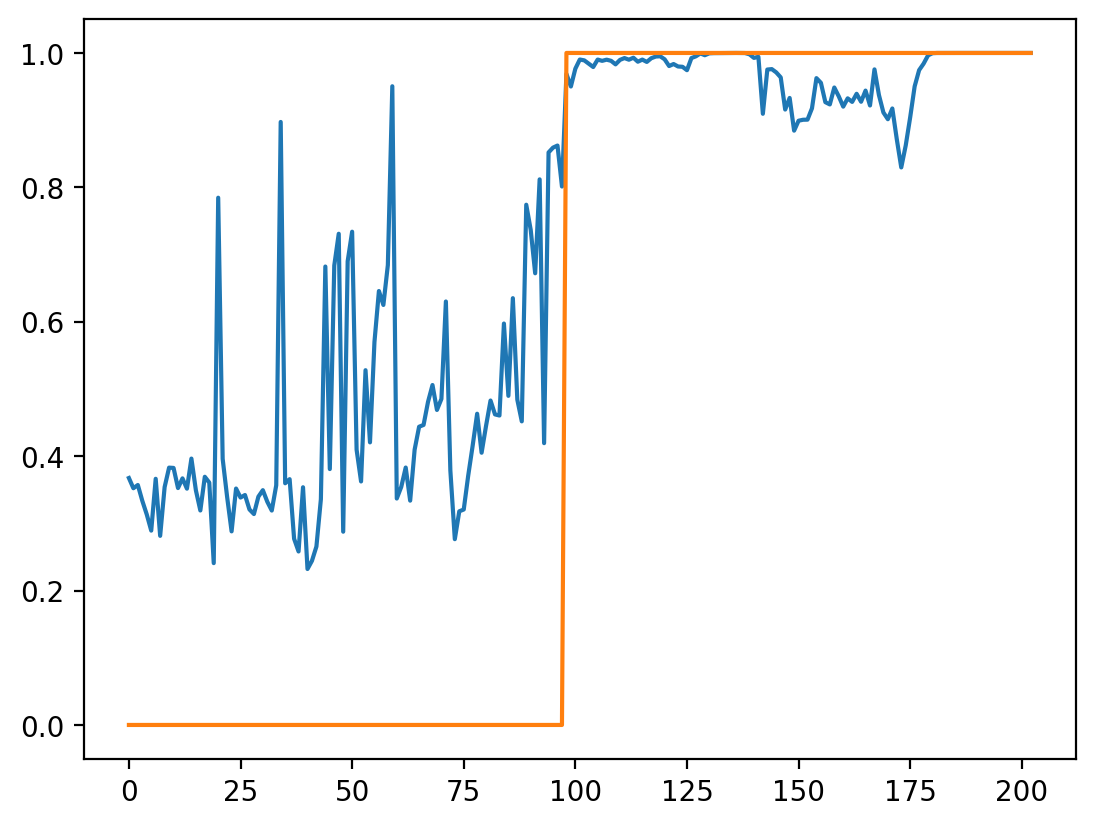

In [173]:
id = 803
plt.plot(ema_causal(all_log[id]['confidence'], alpha=0.9))
plt.plot(all_log[id]['intermediate_correct'])